# Surrogate model evaluation

Runs the exact same offline accuracy evaluation as `evaluator.py`'s `evaluate_surrogate()` -- the same
function used by the `evaluate_surrogate` CLI command -- on every checkpoint currently trained, and
renders the results inline instead of writing JSON + PNG files to disk. Nothing here reimplements the
metrics: every number and every plot below comes from calling `evaluate_surrogate()` itself.
The report separates valid-beam regression from the discontinuous all-particles-lost cliff,
shows native and standardized errors, bootstrap intervals, classifier PR/calibration diagnostics,
checkpoint provenance, and the ensemble mean when multiple checkpoints are available.

When a shared `failure_classifier_*.pt` checkpoint is also found (trained alongside the surrogate
ensemble by `trainer.py`), its precision/recall/F1 at separating true all-particles-lost samples, plus
a "gated" score-metrics block, are reported too -- see section 2 and
[`visualize_surrogate_model.ipynb` section 6](visualize_surrogate_model.ipynb) for why that classifier
exists.

This notebook is read-only: it loads existing checkpoints/datasets and evaluates them in memory, it
does not train, fine-tune, or write anything back to `trained_models/`.

**Related notebooks:**
- [`visualize_surrogate_model.ipynb`](visualize_surrogate_model.ipynb) -- the `ModularMLP` architecture
  being evaluated here (layers, input/output contract), and the `FailureClassifier` (section 6).
- [`env/dataset/visualize_dataset.ipynb`](../../../dataset/visualize_dataset.ipynb) -- the `BeamDataset`
  format the evaluation dataset below is loaded from.

In [1]:
from pathlib import Path
import sys
import tempfile

import numpy as np
import torch
from IPython.display import Image, Markdown, display

WORKING_DIR = Path.cwd().resolve()
if (WORKING_DIR / 'beam_optimization').is_dir():
    REPO_ROOT = WORKING_DIR
else:
    PROJECT_ROOT = WORKING_DIR
    while PROJECT_ROOT.name != 'beam_optimization' and PROJECT_ROOT.parent != PROJECT_ROOT:
        PROJECT_ROOT = PROJECT_ROOT.parent
    REPO_ROOT = PROJECT_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from beam_optimization.config.paths import DEFAULT_BASE_SURROGATE_DIR, DEFAULT_UPDATED_SURROGATE_DIR
from beam_optimization.env.dataset import BeamDataset
from beam_optimization.env.surrogate_env.surrogate.model.modular_mlp import ModularMLP
from beam_optimization.env.surrogate_env.surrogate.model.failure_classifier import FailureClassifier
from beam_optimization.env.surrogate_env.surrogate.model.trainer import compute_normalization_metadata
from beam_optimization.env.surrogate_env.surrogate.model.evaluator import (
    evaluate_surrogate, _default_test_dataset_path, _MeanEnsemble, _checkpoint_provenance,
)


def fmt(value):
    if value is None:
        return 'n/a'
    return f'{float(value):.6g}'


def table(headers, rows):
    lines = ['| ' + ' | '.join(headers) + ' |', '| ' + ' | '.join(['---'] * len(headers)) + ' |']
    lines.extend('| ' + ' | '.join(str(cell) for cell in row) + ' |' for row in rows)
    return '\n'.join(lines)

## Modify here

Pin one surrogate family and its matching held-out dataset below. The notebook validates their
dataset identifiers so that checkpoints trained on different datasets are never mixed silently.

In [2]:
# <-- MODIFY HERE, keeping MODEL_PATTERN and DATASET_PATH_OVERRIDE on the same dataset id.
MODEL_DIR = DEFAULT_BASE_SURROGATE_DIR / 'surrogate_031'
# e.g. MODEL_DIR = Path('beam_optimization/env/surrogate_env/surrogate/trained_models/updated')

MODEL_PATTERN = 'surrogate_031_*.pt'
DATASET_PATH_OVERRIDE = REPO_ROOT / 'beam_optimization/env/dataset/031/dataset_test.pt'
BUILD_ENSEMBLE_MEAN = True  # effective only when the selected family has multiple members

CLASSIFIER_THRESHOLD = 0.5
# Tune this value on dataset_val.pt, then keep it fixed for the final test.

## 1. Checkpoints and evaluation dataset

Only checkpoints matching `MODEL_PATTERN` are evaluated. The dataset identifier encoded in every
checkpoint filename must match the parent directory of `DATASET_PATH_OVERRIDE`; otherwise execution
stops with a clear error. A mean ensemble is built only from members of that same selected family.

In [3]:
checkpoint_paths = sorted(MODEL_DIR.glob(MODEL_PATTERN)) if MODEL_DIR.exists() else []
checkpoint_source = str(MODEL_DIR) if checkpoint_paths else None

DATASET_PATH = DATASET_PATH_OVERRIDE
if not DATASET_PATH.exists():
    raise FileNotFoundError(f'Evaluation dataset not found: {DATASET_PATH}')
dataset_id = DATASET_PATH.parent.name
checkpoint_dataset_ids = {path.stem[len('surrogate_'):].rsplit('_', 1)[0] for path in checkpoint_paths}
if checkpoint_dataset_ids and checkpoint_dataset_ids != {dataset_id}:
    raise ValueError(
        f'Checkpoint/dataset mismatch: models={sorted(checkpoint_dataset_ids)}, dataset={dataset_id}. '
        'Choose one matching surrogate family and held-out split.'
    )
dataset = BeamDataset.load(DATASET_PATH)

print(f'{MODEL_DIR}: {len(checkpoint_paths)} checkpoint(s)')
print(f'evaluating {len(checkpoint_paths)} checkpoint(s) from: {checkpoint_source}')

models = []  # list of (name, model, checkpoint_path)
if checkpoint_paths:
    for path in checkpoint_paths:
        models.append((path.name, ModularMLP.load(str(path)), path))
else:
    norm_stats = compute_normalization_metadata(dataset)
    models.append(('untrained (demo)', ModularMLP(norm_stats=norm_stats), None))
    print(f'\nNo trained checkpoint found in {MODEL_DIR} yet (train one with the `train_surrogate` '
          f'command, or point MODEL_DIR above at a directory that already has one). Evaluating a '
          f'freshly-initialized ModularMLP instead so the rest of this notebook still runs end to '
          f'end -- every metric and plot below will reflect random weights, not real surrogate '
          f'accuracy, until a real checkpoint exists.')

# The shared FailureClassifier (trainer.py trains one per run, independent of ensemble size) lives
# alongside the surrogate_*.pt checkpoints in MODEL_DIR, named failure_classifier_<dataset>.pt.
# Optional: when missing, the rest of the notebook simply reports the regression metrics without the
# classifier section, exactly like evaluate_surrogate() does when classifier=None.
classifier_ckpts = sorted(MODEL_DIR.glob(f'failure_classifier_{dataset_id}.pt')) if MODEL_DIR.exists() else []
if classifier_ckpts:
    classifier = FailureClassifier.load(str(classifier_ckpts[0]))
    classifier.eval()
    print(f'\nLoaded shared failure classifier: {classifier_ckpts[0].name}')
else:
    classifier = None
    print(f'\nNo failure_classifier_*.pt found in {MODEL_DIR} -- '
          f'classifier_metrics/score_metrics_gated will be skipped below.')

print('\nProvenance:')
print(f'  test dataset: {DATASET_PATH.resolve()}')
for name, _, path in models:
    if path is not None:
        provenance = _checkpoint_provenance(path)
        print(f"  {name}: modified={provenance['modified_utc']}, "
              f"train={provenance['train_dataset_path']}, val={provenance['val_dataset_path']}")

[BeamDataset] 12,585 samples loaded from /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/dataset/031/dataset_test.pt
/mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/surrogate_env/surrogate/trained_models/base/surrogate_031: 1 checkpoint(s)
evaluating 1 checkpoint(s) from: /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/surrogate_env/surrogate/trained_models/base/surrogate_031

Loaded shared failure classifier: failure_classifier_031.pt

Provenance:
  test dataset: /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/dataset/031/dataset_test.pt
  surrogate_031_0.pt: modified=2026-08-17T10:51:18.591481+00:00, train=beam_optimization/env/dataset/031/dataset_train.pt, val=beam_optimization/env/dataset/031/dataset_val.pt


## 2. Running `evaluate_surrogate()`

Calls the real function once per model, exactly as `evaluate_surrogate_folder()` does internally:
batched forward passes over the whole dataset, per-(stage, feature) SSE/SAE accumulated in native
physical units, then reduced to MSE/MAE/RMSE per stage, per feature, and overall, plus final-score
metrics (MAE, RMSE, bias, Pearson r, R²) via the project's real `score_tensor()`. `plots_dir` points at
a throwaway temporary directory -- the same plotting code `evaluator.py` uses to save PNGs to disk is
reused untouched, the files are just displayed inline here and discarded afterward instead of being
kept under `results/`.

When a shared `failure_classifier_*.pt` was found in section 1, it is also passed in: `evaluate_surrogate()`
then additionally reports how well it separates true all-particles-lost samples from the rest
(`classifier_metrics` -- precision/recall/F1/confusion matrix) and a second "gated" score-metrics block
computed as if the classifier's override (see `surrogate_simulator.run_surrogate_forward()`) had been
applied to every prediction (`score_metrics_gated`). This never changes the plain `score_metrics` above
it -- it is purely an additional diagnostic, see
[`visualize_surrogate_model.ipynb` section 6](visualize_surrogate_model.ipynb#6.-FailureClassifier:-gating-the-all-particles-lost-cliff)
for why the classifier exists and how it's trained.

In [4]:
all_results = {}
with tempfile.TemporaryDirectory() as tmp:
    tmp_dir = Path(tmp)
    for name, model, checkpoint_path in models:
        all_results[name] = evaluate_surrogate(
            model, dataset, plots_dir=tmp_dir, plot_prefix=Path(name).stem,
            classifier=classifier, classifier_threshold=CLASSIFIER_THRESHOLD,
        )
        if checkpoint_path is not None:
            all_results[name]['checkpoint_provenance'] = _checkpoint_provenance(checkpoint_path)
        # Plot PNGs must be read into memory now, inside the `with` block, before the
        # temporary directory (and the files in it) are deleted on exit.
        for plot_name, plot_path in all_results[name]['plots'].items():
            all_results[name]['plots'][plot_name] = Path(plot_path).read_bytes()

    if BUILD_ENSEMBLE_MEAN and len(models) > 1 and all(path is not None for _, _, path in models):
        ensemble = _MeanEnsemble([model for _, model, _ in models])
        all_results['ensemble_mean'] = evaluate_surrogate(
            ensemble, dataset, plots_dir=tmp_dir, plot_prefix='ensemble_mean',
            classifier=classifier, classifier_threshold=CLASSIFIER_THRESHOLD,
        )
        all_results['ensemble_mean']['ensemble_size'] = len(models)
        for plot_name, plot_path in all_results['ensemble_mean']['plots'].items():
            all_results['ensemble_mean']['plots'][plot_name] = Path(plot_path).read_bytes()

print(f'Evaluated {len(all_results)} report(s) on {len(dataset):,} samples from {DATASET_PATH.name}.')
if len(models) == 1:
    print('Only one checkpoint is available: ensemble uncertainty cannot be evaluated yet.')

Evaluated 1 report(s) on 12,585 samples from dataset_test.pt.
Only one checkpoint is available: ensemble uncertainty cannot be evaluated yet.


## 3. Report, per model

### `surrogate_031_0.pt`

**Summary**

| Metric | Value |
| --- | --- |
| Samples | 12,585 |
| Physical non-failure / all lost | 10,301 / 2,284 |
| RL-valid (>= 10%) / terminal (< 10%) | 6,335 / 6,250 |
| RMSE all stages (native units) | 10.1761 |
| NRMSE all stages (dimensionless) | 0.699233 |
| RMSE final stage (native units) | 1.2554 |

**Score metrics split by physical regime**

| Group | N | MAE | MAE 95% CI | RMSE | Bias | Pearson r | R² |
| --- | --- | --- | --- | --- | --- | --- | --- |
| All samples (regressor only) | 12,585 | 186.222 | [179.576, 193.627] | 428.744 | 183.654 | -0.105734 | -0.233521 |
| Physical non-failure (npart > 0) | 10,301 | 4.3878 | [4.30167, 4.48105] | 6.49327 | 1.25113 | 0.915388 | 0.819337 |
| All particles lost (npart = 0) | 2,284 | 1006.31 | [1006.07, 1006.55] | 1006.32 | 1006.31 | n/a | n/a |
| RL-valid (npart >= 0.10) | 6,335 | 3.4464 | [3.36936, 3.51546] | 4.61225 | -1.3382 | 0.925838 | 0.843557 |
| RL-terminal (npart < 0.10) | 6,250 | 371.483 | [360.092, 383.539] | 608.376 | 371.163 | -0.679103 | -0.637855 |

> The all-sample regressor metric includes the discontinuous ERROR_SCORE cliff. For RL, use the npart >= 0.10 row: physical non-failure (npart > 0) is a different split.

**RL terminal decision at `npart_ratio < 0.10`** — exactly 0.10 remains valid.

| Decision source | Precision | Recall | Specificity | F1 | Balanced accuracy | TP / FP / FN / TN |
| --- | --- | --- | --- | --- | --- | --- |
| npart regressor only | 0.893295 | 0.95504 | 0.887451 | 0.923136 | 0.921245 | 5969 / 713 / 281 / 5622 |
| Optional combined gate: npart regressor OR classifier | 0.893449 | 0.95792 | 0.887293 | 0.924562 | 0.922606 | 5987 / 714 / 263 / 5621 |

**Final `npart_ratio` by operational band**

| True band | N | True mean | Predicted mean | MAE | Bias | Regressor terminal rate | Classifier flag rate | Pipeline terminal rate |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| npart_ratio <= 0 | 2,284 | 0 | 0.0151978 | 0.0151978 | 0.0151978 | 0.991243 | 0.96366 | 0.997373 |
| 0 < npart_ratio < 0.1 | 3,966 | 0.0418106 | 0.046712 | 0.0154831 | 0.00490145 | 0.934191 | 0.0922844 | 0.935199 |
| 0.1 <= npart_ratio < 0.25 | 4,156 | 0.169181 | 0.150811 | 0.0322092 | -0.01837 | 0.16025 | 0.0346487 | 0.160491 |
| npart_ratio >= 0.25 | 2,179 | 0.330204 | 0.282242 | 0.0530231 | -0.0479617 | 0.0215695 | 0.0169803 | 0.0215695 |

> A terminal rate should be high in the first two rows and low in the RL-valid rows. The classifier is trained only for npart = 0; the continuous npart regressor carries the 10% decision.

**Per-feature errors**

| Feature | RMSE all | MAE all | RMSE final | NRMSE final | Target std final |
| --- | --- | --- | --- | --- | --- |
| `npart_ratio` | 0.0846641 | 0.032281 | 0.0433063 | 0.359276 | 0.120538 |
| `x0` | 5.25911 | 1.14227 | 1.23509 | 0.501461 | 2.46298 |
| `y0` | 6.83325 | 0.897526 | 1.02568 | 0.337581 | 3.03831 |
| `SizeX` | 6.23029 | 1.1645 | 0.78855 | 0.423495 | 1.862 |
| `SizeY` | 6.36779 | 0.93646 | 0.934233 | 0.584693 | 1.59782 |
| `ex` | 3.74747 | 0.267412 | 0.0101372 | 0.58115 | 0.0174433 |
| `ey` | 0.512717 | 0.0503512 | 0.0144843 | 0.57191 | 0.0253263 |
| `x'0` | 26.8251 | 2.47739 | 2.01746 | 0.326358 | 6.18174 |
| `y'0` | 6.66046 | 1.16519 | 2.45761 | 0.374502 | 6.56235 |

**Per-stage errors** — raw RMSE mixes physical units; NRMSE is the comparable column.

| Stage marker | RMSE native | NRMSE |
| --- | --- | --- |
| 2 | 0.276312 | 1.0205 |
| 29 | 0.184116 | 0.997348 |
| 108 | 0.234853 | 0.688365 |
| 151 | 0.327954 | 0.691321 |
| 162 | 0.577943 | 0.718012 |
| 195 | 0.684552 | 0.684374 |
| 197 | 34.1622 | 0.777058 |
| 203 | 4.54884 | 0.579715 |
| 205 | 6.63415 | 0.534121 |
| 225 | 1.80119 | 0.460479 |
| 261 | 2.23178 | 0.493929 |
| 332 | 1.2554 | 0.462757 |

**Failures incorrectly accepted as valid**

| Criterion | False OK | Rate over true failures | Rate among accepted samples |
| --- | --- | --- | --- |
| Classifier says OK (P_failure <= 0.5) | 3,683 | 58.93% | 37.44% |
| Predicted npart_ratio >= 0.10 | 281 | 4.50% | 4.76% |

> A false OK is a sample with true TraceWin `npart_ratio < 0.10` that the criterion nevertheless accepts as valid.

**Checkpoint provenance**

| Field | Value |
| --- | --- |
| Path | /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/surrogate_env/surrogate/trained_models/base/surrogate_031/surrogate_031_0.pt |
| Modified UTC | 2026-08-17T10:51:18.591481+00:00 |
| Training dataset | beam_optimization/env/dataset/031/dataset_train.pt |
| Validation dataset | beam_optimization/env/dataset/031/dataset_val.pt |
| Best validation loss | 111.63 |

**Failure classifier at the fixed threshold `0.5`**

| Metric | Value |
| --- | --- |
| Precision | 0.800946 |
| Recall | 0.96366 |
| F1 | 0.874801 |
| Accuracy | 0.94994 |
| Average precision | 0.915142 |
| Brier score | 0.0405939 |
| Expected calibration error | 0.0348159 |
| Confusion matrix (tp/fp/fn/tn) | 2201 / 547 / 83 / 9754 |

**Full pipeline with classifier gate**

| Metric | Value |
| --- | --- |
| MAE | 52.6302 |
| RMSE | 222.035 |
| Bias | -36.0028 |
| Pearson r | 0.852343 |
| R² | 0.669179 |

**Threshold diagnostics (descriptive only)**

> ⚠️ Choose the threshold on `dataset_val.pt`; never select it from this final test table.

| Threshold | Precision | Recall | Gated MAE | Gated R² |
| --- | --- | --- | --- | --- |
| 0.05 | 0.675796 | 0.99387 | 89.1536 | 0.425724 |
| 0.1 | 0.712217 | 0.990368 | 76.2171 | 0.511897 |
| 0.15 | 0.733204 | 0.989054 | 69.3109 | 0.557915 |
| 0.2 | 0.745442 | 0.984676 | 65.9306 | 0.580473 |
| 0.25 | 0.758108 | 0.982487 | 62.3072 | 0.604634 |
| 0.3 | 0.770131 | 0.97986 | 59.0623 | 0.626321 |
| 0.35 | 0.779058 | 0.977233 | 56.8268 | 0.641258 |
| 0.4 | 0.78617 | 0.970665 | 55.6892 | 0.648772 |
| 0.45 | 0.793811 | 0.965849 | 54.2476 | 0.658355 |
| 0.5 | 0.800946 | 0.96366 | 52.6302 | 0.669179 |
| 0.5 | 0.800946 | 0.96366 | 52.6302 | 0.669179 |
| 0.55 | 0.806914 | 0.960595 | 51.4835 | 0.676862 |
| 0.6 | 0.81476 | 0.957093 | 49.9568 | 0.68708 |
| 0.65 | 0.819789 | 0.954028 | 49.1277 | 0.692576 |
| 0.7 | 0.827994 | 0.950525 | 47.5869 | 0.702855 |
| 0.75 | 0.833333 | 0.941331 | 47.6383 | 0.702451 |
| 0.8 | 0.839779 | 0.931699 | 47.5417 | 0.70312 |
| 0.85 | 0.84603 | 0.919002 | 48.0026 | 0.699984 |
| 0.9 | 0.853065 | 0.889667 | 50.8555 | 0.680916 |
| 0.95 | 0.896572 | 0.664186 | 78.396 | 0.495152 |

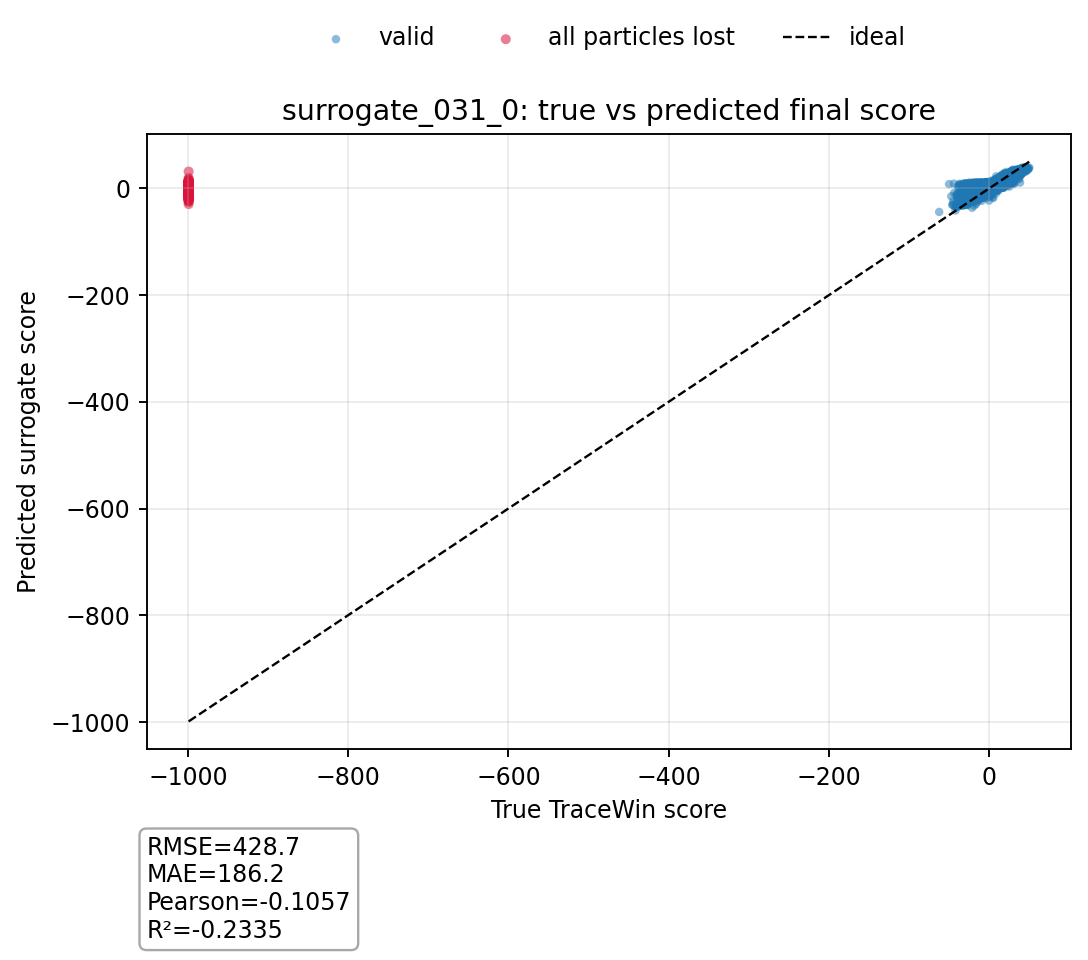

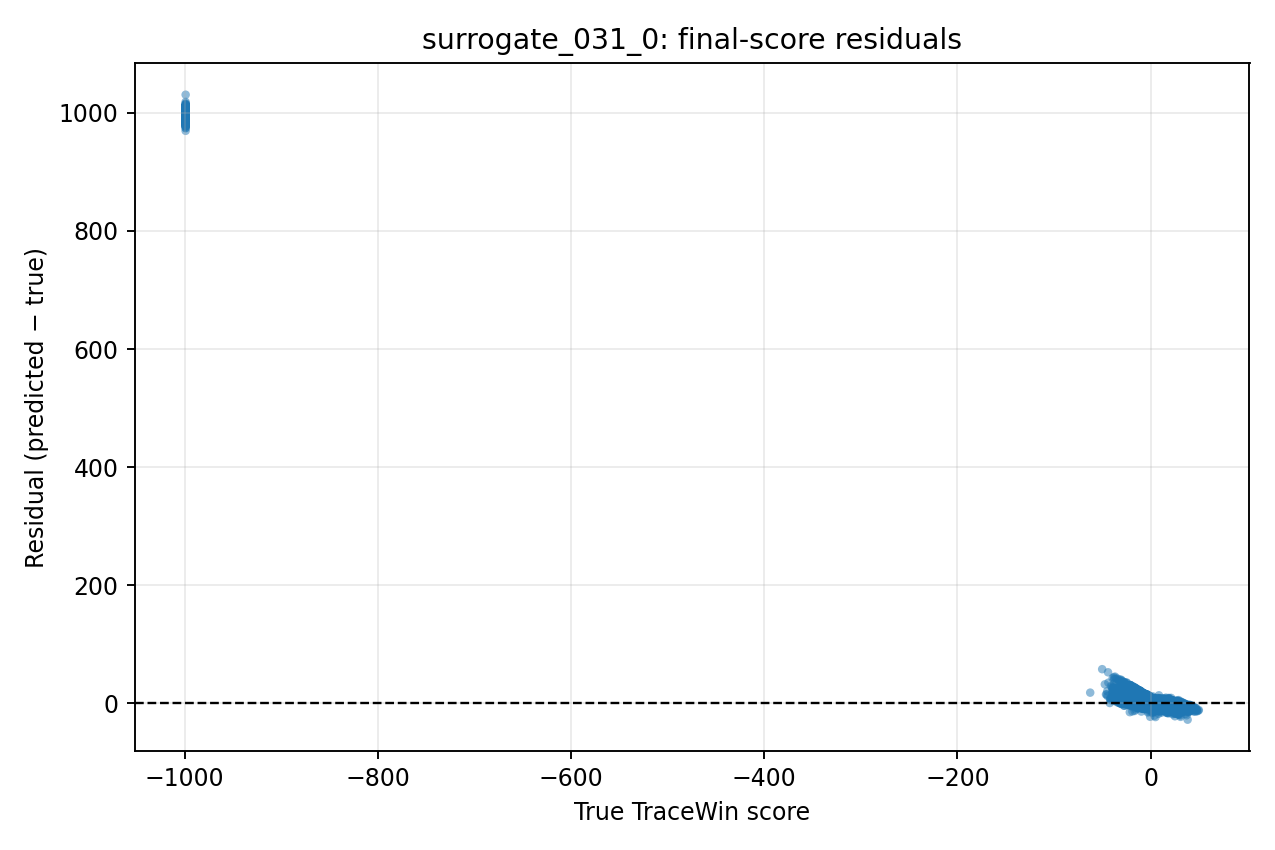

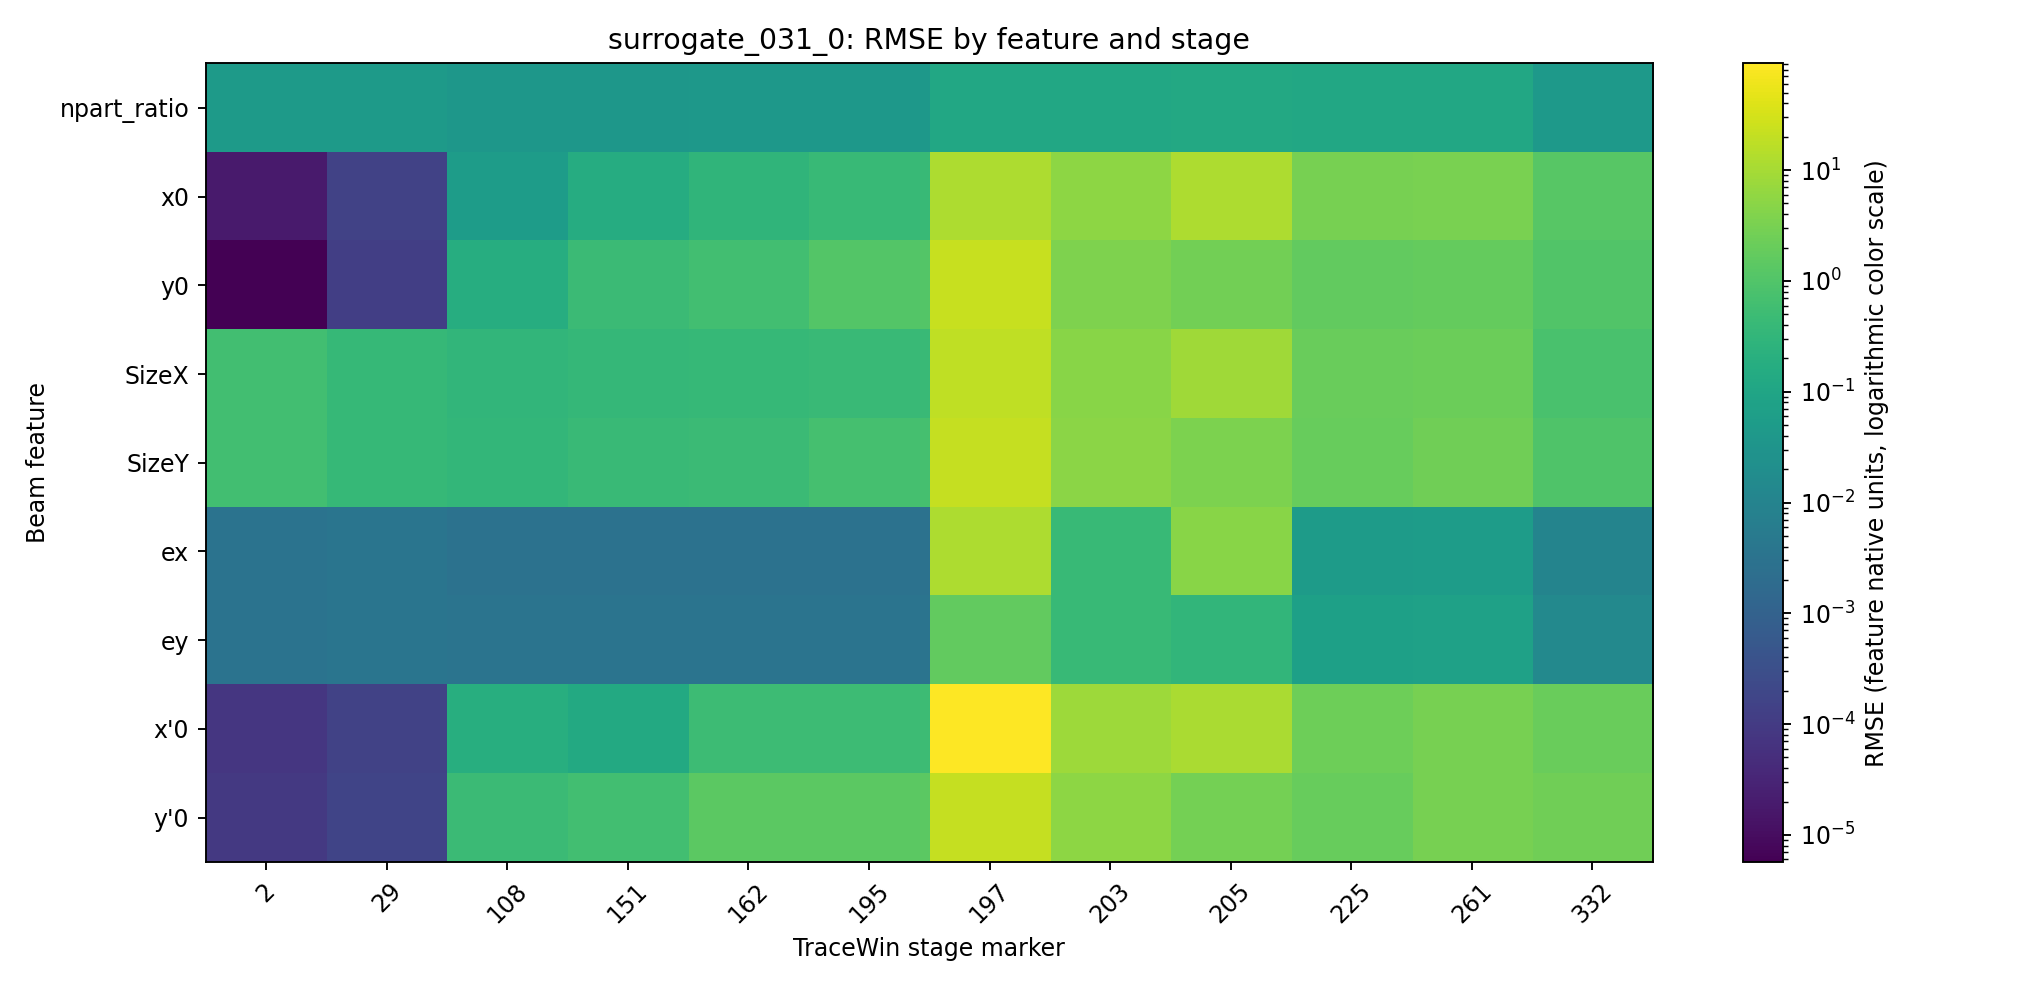

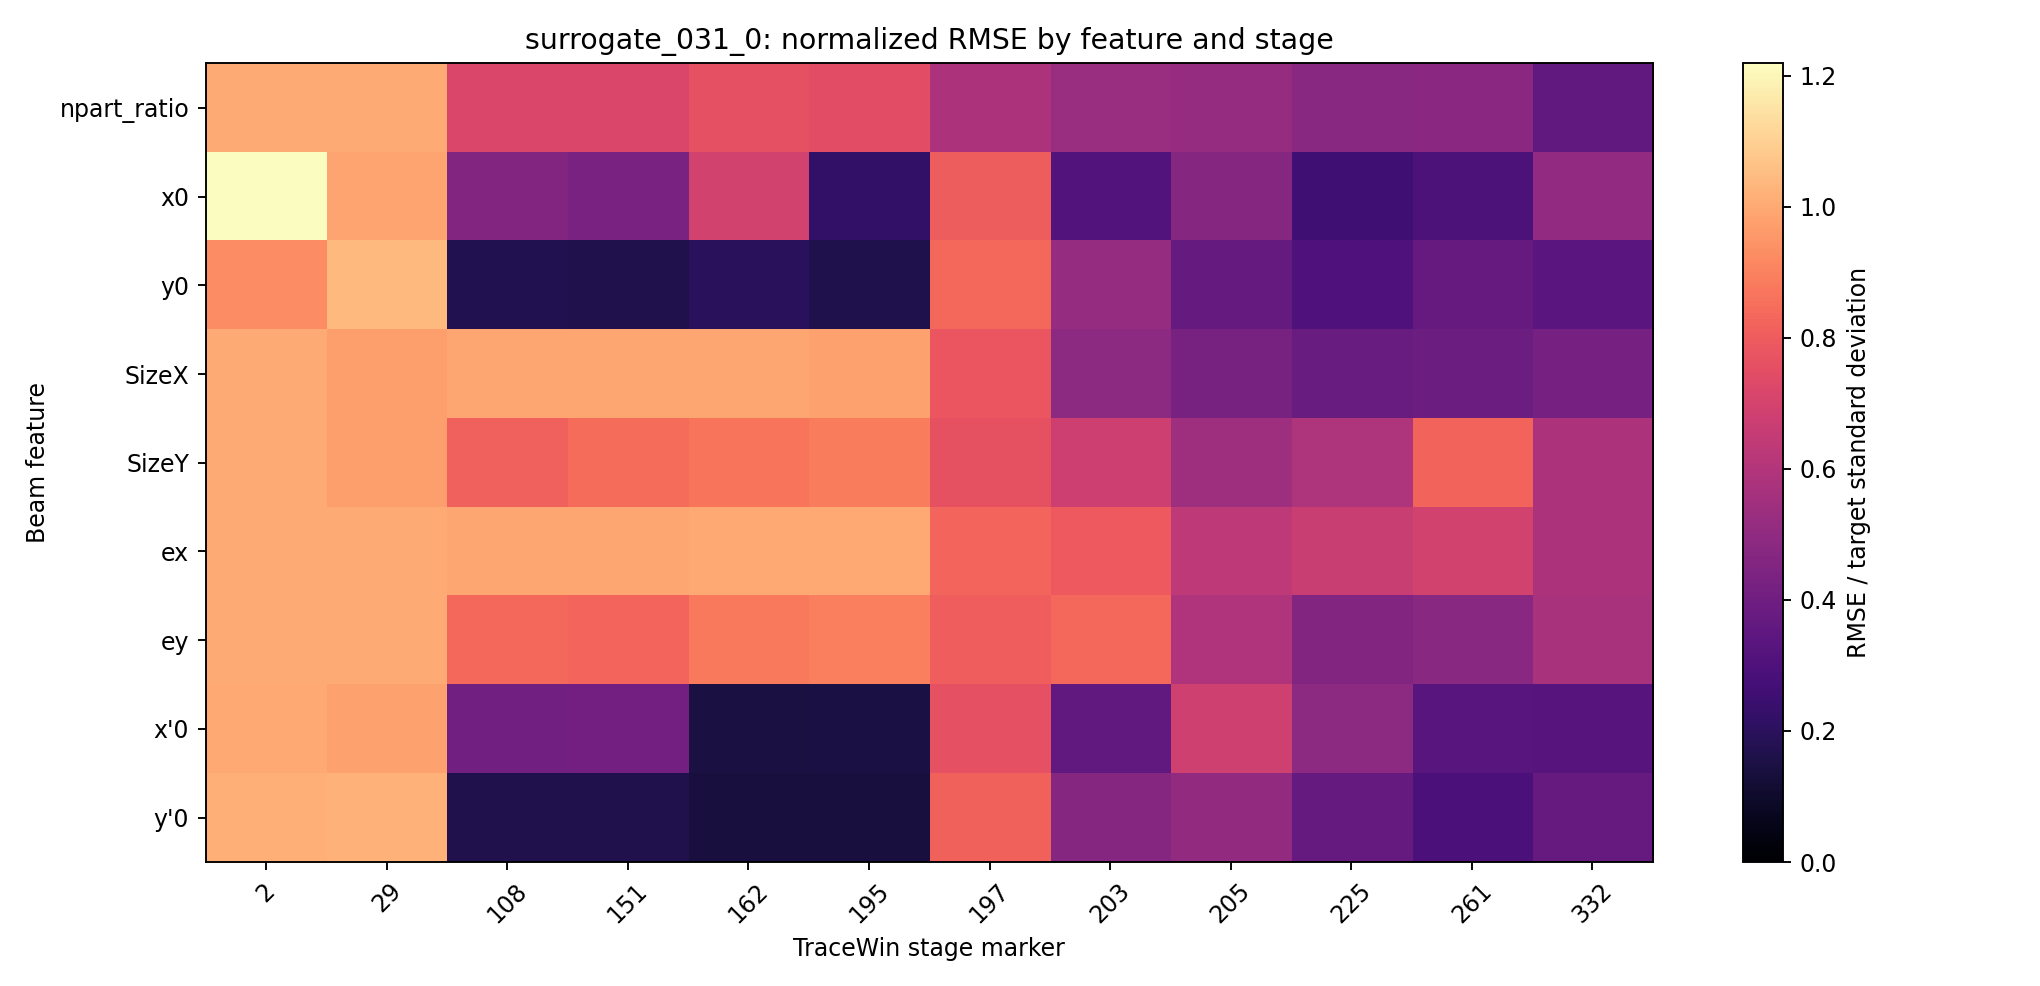

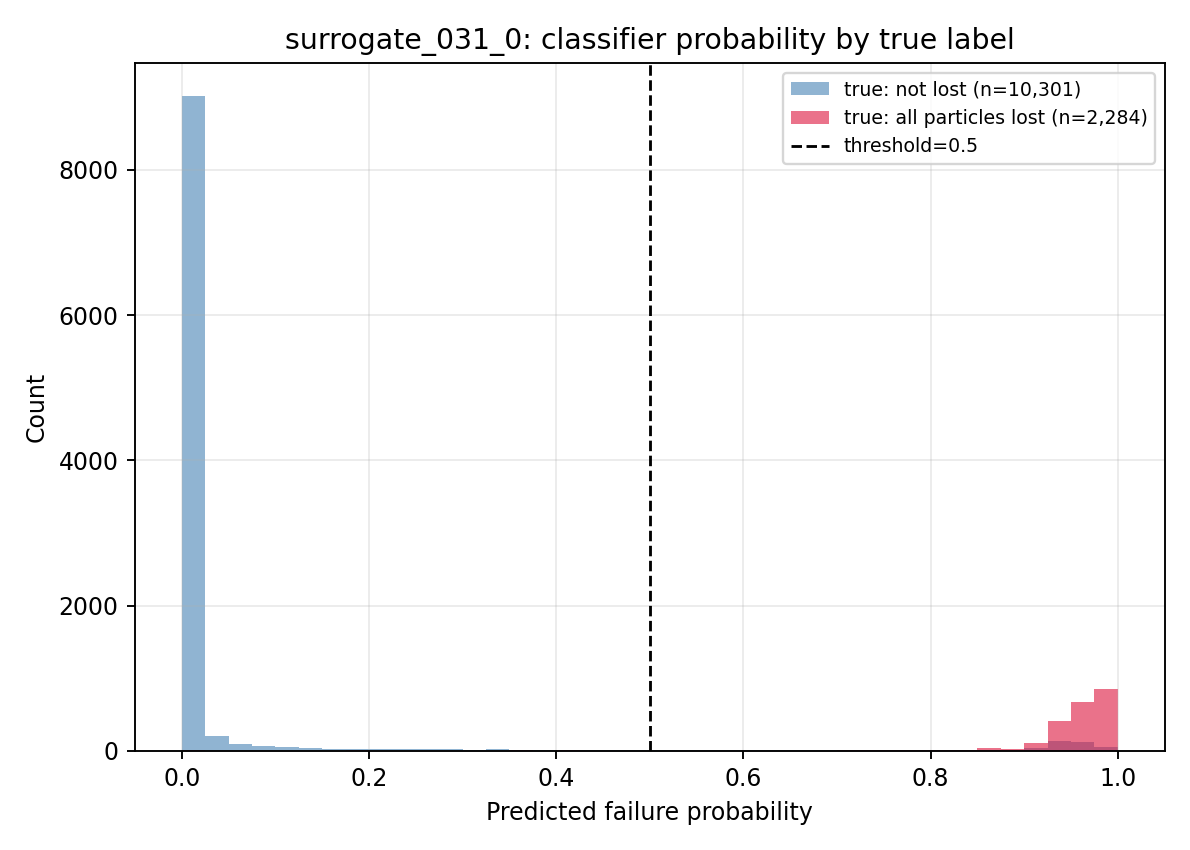

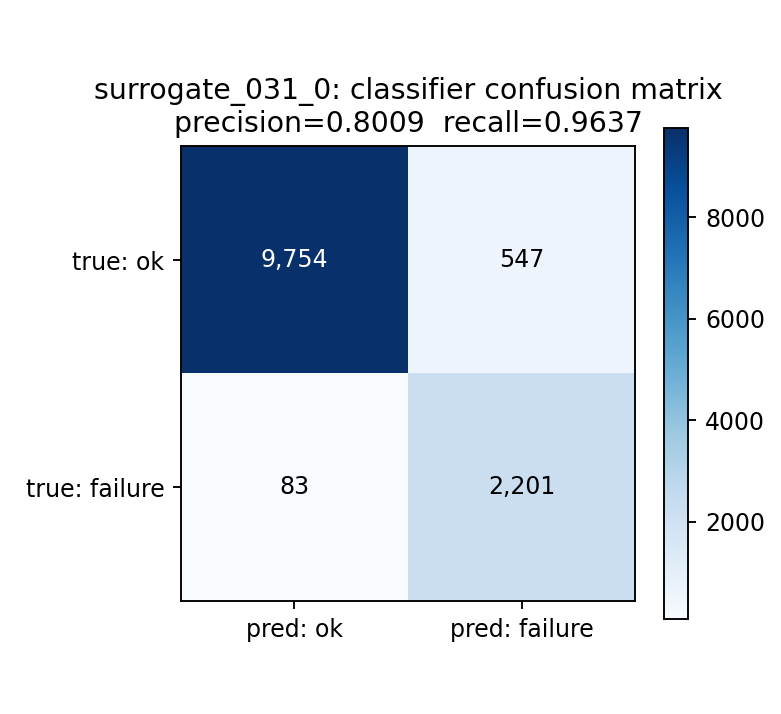

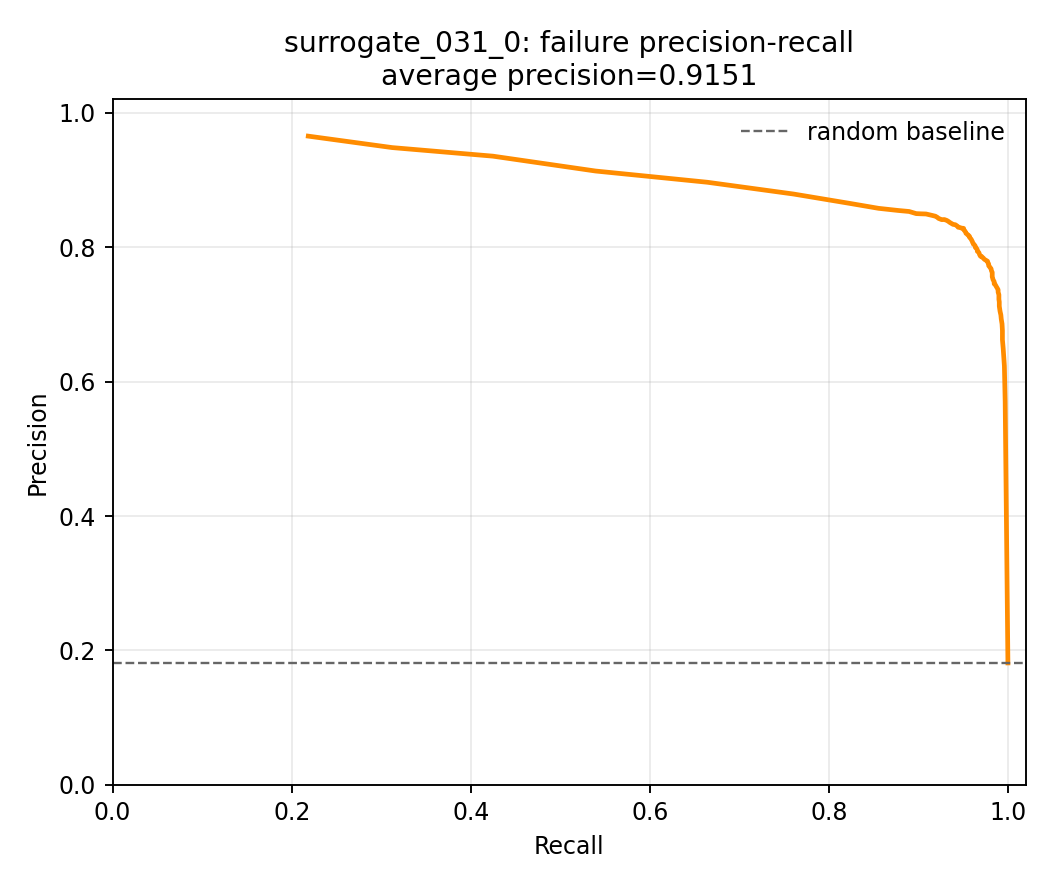

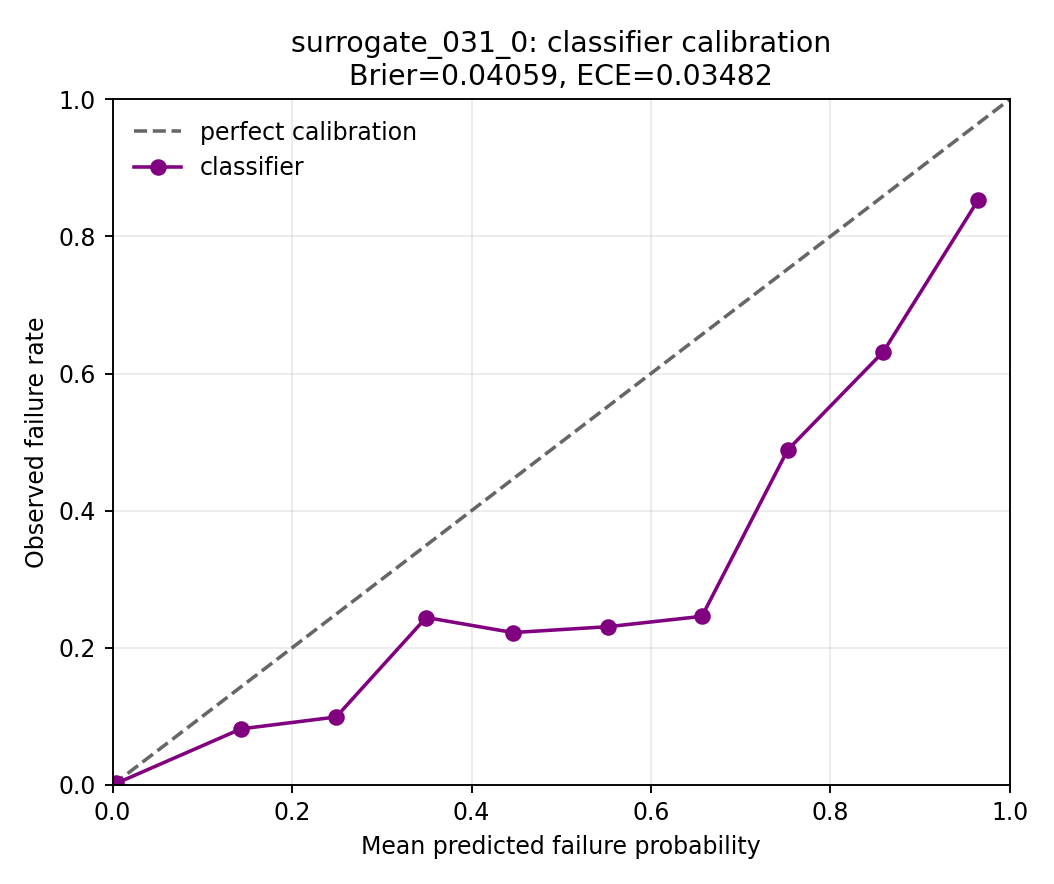

In [5]:
for name, metrics in all_results.items():
    groups = metrics['sample_groups']
    rl_groups = metrics['rl_sample_groups']
    summary_rows = [
        ['Samples', f"{metrics['n_samples']:,}"],
        ['Physical non-failure / all lost', f"{groups['n_valid']:,} / {groups['n_failures']:,}"],
        ['RL-valid (>= 10%) / terminal (< 10%)', f"{rl_groups['n_valid']:,} / {rl_groups['n_terminal']:,}"],
        ['RMSE all stages (native units)', fmt(metrics['rmse_all'])],
        ['NRMSE all stages (dimensionless)', fmt(metrics['nrmse_all'])],
        ['RMSE final stage (native units)', fmt(metrics['rmse_final_stage'])],
    ]
    score_rows = []
    for label, key, count in [
        ('All samples (regressor only)', 'score_metrics', metrics['n_samples']),
        ('Physical non-failure (npart > 0)', 'score_metrics_valid', groups['n_valid']),
        ('All particles lost (npart = 0)', 'score_metrics_failures', groups['n_failures']),
        ('RL-valid (npart >= 0.10)', 'score_metrics_rl_valid', rl_groups['n_valid']),
        ('RL-terminal (npart < 0.10)', 'score_metrics_rl_terminal', rl_groups['n_terminal']),
    ]:
        values = metrics[key]
        mae_ci = values.get('confidence_intervals_95', {}).get('mae', {})
        mae_ci_text = (f"[{fmt(mae_ci.get('low'))}, {fmt(mae_ci.get('high'))}]" if mae_ci else 'n/a')
        score_rows.append([
            label, f'{count:,}', fmt(values['mae']), mae_ci_text, fmt(values['rmse']),
            fmt(values['bias']), fmt(values['pearson_correlation']), fmt(values['r2']),
        ])
    feature_rows = [
        [f"`{feature}`", fmt(values['rmse_all_stages']), fmt(values['mae_all_stages']),
         fmt(values['rmse_final_stage']), fmt(values['nrmse_final_stage']),
         fmt(values['target_std_final_stage'])]
        for feature, values in metrics['feature_metrics'].items()
    ]
    stage_rows = [
        [marker, fmt(rmse), fmt(nrmse)]
        for marker, rmse, nrmse in zip(
            metrics['stage_markers'], metrics['rmse_per_stage'], metrics['nrmse_per_stage']
        )
    ]
    terminal_rows = []
    for label, key in [('npart regressor only', 'regressor_only'),
                       ('Optional combined gate: npart regressor OR classifier', 'with_classifier_gate')]:
        values = metrics['rl_terminal_metrics'].get(key)
        if values is None:
            continue
        confusion = values['confusion_matrix']
        terminal_rows.append([
            label, fmt(values['precision']), fmt(values['recall']), fmt(values['specificity']),
            fmt(values['f1']), fmt(values['balanced_accuracy']),
            f"{confusion['tp']} / {confusion['fp']} / {confusion['fn']} / {confusion['tn']}",
        ])
    band_rows = [
        [row['interval'], f"{row['n_samples']:,}", fmt(row['true_mean']),
         fmt(row['predicted_mean']), fmt(row['mae']), fmt(row['bias']),
         fmt(row['regressor_terminal_rate']), fmt(row['classifier_flag_rate']),
         fmt(row['pipeline_terminal_rate'])]
        for row in metrics['npart_ratio_bands']
    ]
    ok_comparison = metrics.get('ok_criterion_comparison')
    ok_criterion_rows = []
    if ok_comparison is not None:
        reference = ok_comparison['reference']
        n_true_failures = reference['n_samples'] - reference['n_true_rl_valid']
        criterion_labels = {
            'classifier_ok': 'Classifier says OK (P_failure <= 0.5)',
            'predicted_transmission_ok': 'Predicted npart_ratio >= 0.10',
        }
        for key, label in criterion_labels.items():
            values = ok_comparison['criteria'][key]
            false_ok = values['n_unsafe_accepted']
            ok_criterion_rows.append([
                label, f'{false_ok:,}', f'{100.0 * false_ok / n_true_failures:.2f}%',
                f"{100.0 * false_ok / values['n_accepted']:.2f}%",
            ])
    sections = [
        f'### `{name}`',
        '**Summary**', table(['Metric', 'Value'], summary_rows),
        '**Score metrics split by physical regime**',
        table(['Group', 'N', 'MAE', 'MAE 95% CI', 'RMSE', 'Bias', 'Pearson r', 'R²'], score_rows),
        '> The all-sample regressor metric includes the discontinuous ERROR_SCORE cliff. '
        'For RL, use the npart >= 0.10 row: physical non-failure (npart > 0) is a different split.',
        '**RL terminal decision at `npart_ratio < 0.10`** — exactly 0.10 remains valid.',
        table(['Decision source', 'Precision', 'Recall', 'Specificity', 'F1',
               'Balanced accuracy', 'TP / FP / FN / TN'], terminal_rows),
        '**Final `npart_ratio` by operational band**',
        table(['True band', 'N', 'True mean', 'Predicted mean', 'MAE', 'Bias',
               'Regressor terminal rate', 'Classifier flag rate', 'Pipeline terminal rate'], band_rows),
        '> A terminal rate should be high in the first two rows and low in the RL-valid rows. '
        'The classifier is trained only for npart = 0; the continuous npart regressor carries the 10% decision.',
        '**Per-feature errors**',
        table(['Feature', 'RMSE all', 'MAE all', 'RMSE final', 'NRMSE final', 'Target std final'], feature_rows),
        '**Per-stage errors** — raw RMSE mixes physical units; NRMSE is the comparable column.',
        table(['Stage marker', 'RMSE native', 'NRMSE'], stage_rows),
    ]
    if ok_comparison is not None:
        sections += [
            '**Failures incorrectly accepted as valid**',
            table(
                ['Criterion', 'False OK', 'Rate over true failures', 'Rate among accepted samples'],
                ok_criterion_rows,
            ),
            '> A false OK is a sample with true TraceWin `npart_ratio < 0.10` that the criterion '
            'nevertheless accepts as valid.',
        ]
    provenance = metrics.get('checkpoint_provenance')
    if provenance:
        sections += ['**Checkpoint provenance**', table(['Field', 'Value'], [
            ['Path', provenance['path']], ['Modified UTC', provenance['modified_utc']],
            ['Training dataset', provenance['train_dataset_path']],
            ['Validation dataset', provenance['val_dataset_path']],
            ['Best validation loss', fmt(provenance['best_val_loss'])],
        ])]
    if metrics.get('classifier_metrics'):
        cm = metrics['classifier_metrics']; diag = metrics['classifier_diagnostics']
        gated = metrics['score_metrics_gated']
        cm_rows = [
            ['Precision', fmt(cm['precision'])], ['Recall', fmt(cm['recall'])],
            ['F1', fmt(cm['f1'])], ['Accuracy', fmt(cm['accuracy'])],
            ['Average precision', fmt(diag['average_precision'])],
            ['Brier score', fmt(diag['brier_score'])],
            ['Expected calibration error', fmt(diag['expected_calibration_error'])],
            ['Confusion matrix (tp/fp/fn/tn)',
             f"{cm['confusion_matrix']['tp']:.0f} / {cm['confusion_matrix']['fp']:.0f} / "
             f"{cm['confusion_matrix']['fn']:.0f} / {cm['confusion_matrix']['tn']:.0f}"],
        ]
        gated_rows = [['MAE', fmt(gated['mae'])], ['RMSE', fmt(gated['rmse'])],
                      ['Bias', fmt(gated['bias'])], ['Pearson r', fmt(gated['pearson_correlation'])],
                      ['R²', fmt(gated['r2'])]]
        sweep_rows = [
            [fmt(row['threshold']), fmt(row['precision']), fmt(row['recall']),
             fmt(row['gated_score_mae']), fmt(row['gated_score_r2'])]
            for row in diag['threshold_diagnostics']
        ]
        sections += [
            f"**Failure classifier at the fixed threshold `{cm['threshold']}`**",
            table(['Metric', 'Value'], cm_rows),
            '**Full pipeline with classifier gate**', table(['Metric', 'Value'], gated_rows),
            '**Threshold diagnostics (descriptive only)**',
            '> ⚠️ Choose the threshold on `dataset_val.pt`; never select it from this final test table.',
            table(['Threshold', 'Precision', 'Recall', 'Gated MAE', 'Gated R²'], sweep_rows),
        ]
    display(Markdown('\n\n'.join(sections)))
    for plot_name, plot_bytes in metrics['plots'].items():
        display(Image(data=plot_bytes))

## 4. Where this fits in the pipeline

- This notebook is the interactive, always-available counterpart to running
  `python -m beam_optimization.env.surrogate_env.surrogate.model.evaluator --model-dir <dir> --dataset <path>`
  directly -- same `evaluate_surrogate()` call, same numbers, just rendered here instead of written to
  `results/benchmark/surrogate_eval.json` and standalone PNGs.
- See [`visualize_surrogate_model.ipynb`](visualize_surrogate_model.ipynb) for what the model being
  evaluated actually looks like (layers, parameters, forward pass), and `trainer.py` for how a real
  checkpoint gets produced in the first place (`train_surrogate` command).
- If section 1 above evaluated an `'untrained (demo)'` model, none of the numbers or plots in this
  notebook reflect real surrogate accuracy -- re-run the notebook once a checkpoint exists under
  `trained_models/base/` or `trained_models/updated/`.